In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys, torch, matplotlib
from sbi.utils import MultipleIndependent
from torch.distributions import Uniform
from torch import nn
from sbi import utils as utils
from sbi.analysis import pairplot
from sbi.inference import NPE
import scipy.stats as st
import os, pickle
from matplotlib.gridspec import GridSpec
from pathlib import Path
PROJECT_DIR = Path.cwd().parent  # notebooks/ -> repository root
sys.path.insert(0, str(PROJECT_DIR))
from scripts.python.config import (
    DATA_DIR, RESULTS_DIR, ATLAS_LUT, FMRI_DIR, BIFURCATION_DIR,
    TRAINED_MODELS_DIR, SUBJECT, connectome, require,
)
from sbi.neural_nets import posterior_nn

/Users/martinbreyton/INS_Code/data-driven_whole-brain/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
results_path = RESULTS_DIR / 'sbi_homogeneous'
atlas_LUT = ATLAS_LUT
lut_aseg  = np.genfromtxt(atlas_LUT, usecols=0, dtype=int)[1:101]
lut_names = np.genfromtxt(atlas_LUT, usecols=1, dtype=str)[1:101]
names = ['_'.join(name.split('_')[1:3]) for name in lut_names]
names_idx = sorted([names.index(name) for name in set(names)])

In [3]:
GT_MPR = np.load('artifacts/gt_params_mpr.npy')
GT_MLP = np.load('artifacts/gt_params_mlp_qif.npy')


In [4]:
MAPS_mlp = []
real_MAPS_mlp_qif = []
for i, gt in enumerate(GT_MLP):
    print(f'{i}/{len(GT_MLP)}', end='\r')
    with open('artifacts/posterior_mlp_qif_sims.pkl', 'rb') as f:
        posterior = pickle.load(f)
    posterior.set_default_x(gt[3:].astype('float32'))
    rs = posterior.sample((10000,), show_progress_bars=False)
    # m = posterior.map(show_progress_bars=False)
    # real_MAPS_mlp_qif.append(m)
    MAPS_mlp.append(rs)

In [5]:
MAPS_crossed = []
real_MAPS_crossed = []
for i, gt in enumerate(GT_MLP):
    print(f'{i}/{len(GT_MLP)}', end='\r')
    with open('artifacts/posterior_mpr_sims.pkl', 'rb') as f:
        posterior = pickle.load(f)
    posterior.set_default_x(gt[3:].astype('float32'))
    rs = posterior.sample((10000,), show_progress_bars=False)
    # m = posterior.map(show_progress_bars=False)
    # real_MAPS_crossed.append(m)
    MAPS_crossed.append(rs)

/var/folders/ht/k1bq940j1nzdxy0vc8gf2_d40000gn/T/ipykernel_99634/3602135122.py:41: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x=s, y=z, c='k', s=15, cmap='viridis', alpha=.1, marker='x')
/var/folders/ht/k1bq940j1nzdxy0vc8gf2_d40000gn/T/ipykernel_99634/3602135122.py:41: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x=s, y=z, c='k', s=15, cmap='viridis', alpha=.1, marker='x')
/var/folders/ht/k1bq940j1nzdxy0vc8gf2_d40000gn/T/ipykernel_99634/3602135122.py:41: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x=s, y=z, c='k', s=15, cmap='viridis', alpha=.1, marker='x')
/var/folders/ht/k1bq940j1nzdxy0vc8gf2_d40000gn/T/ipykernel_99634/3602135122.py:43: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax.scatter(x=s, y

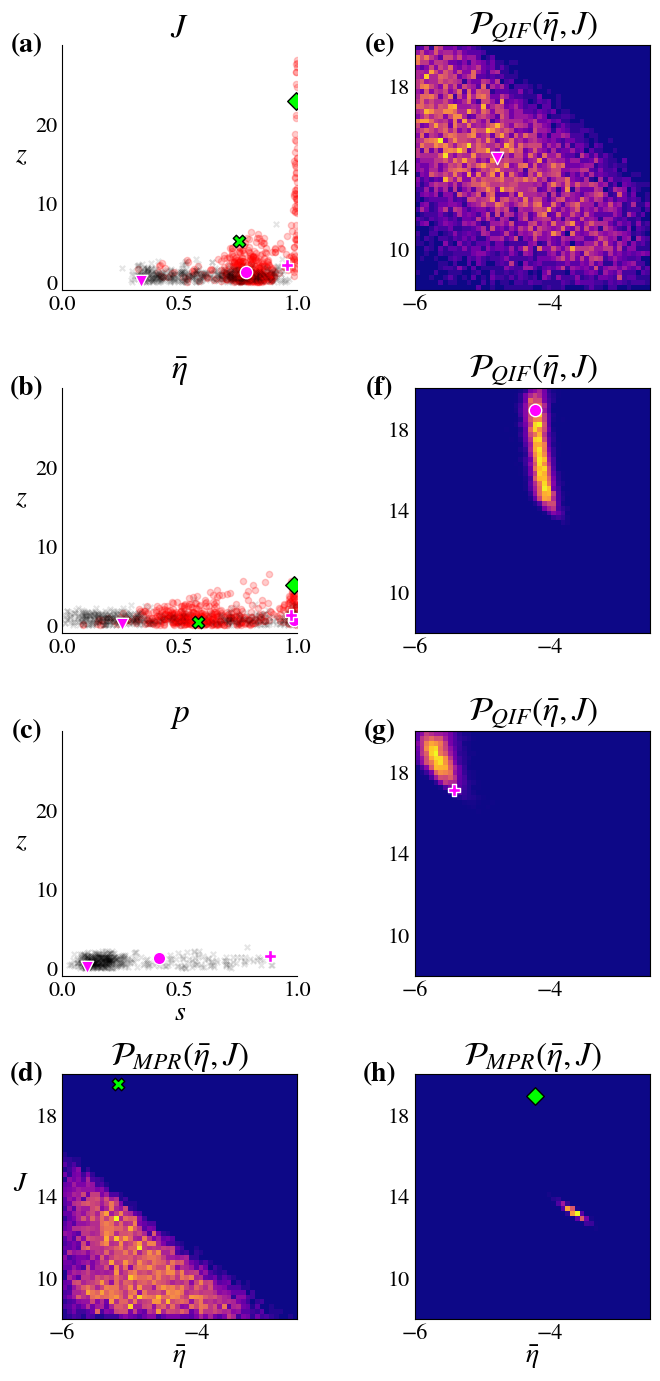

In [8]:
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['font.size']=20
matplotlib.rcParams['xtick.labelsize']=16
matplotlib.rcParams['ytick.labelsize']=16
matplotlib.rcParams['ytick.labelsize']=16
plt.style.use('_mpl-gallery')
networks = np.array([name.split('_')[1] for name in names[:50]])[names_idx[:7]]
fig = plt.figure(figsize=(6,13))
grid = GridSpec(ncols=2, nrows=4, figure=fig)
ax1 = fig.add_subplot(grid[0,0])
ax2 = fig.add_subplot(grid[1,0], sharex=ax1, sharey=ax1)
ax3 = fig.add_subplot(grid[2,0], sharex=ax1, sharey=ax1)
axes = np.array([ax1, ax2, ax3])

# grid = GridSpec(ncols=3, nrows=3, figure=fig)
# axes = np.array([fig.add_subplot(grid[i,:]) for i in range(0,3)])
ss = []
zz = []
axes_left = []
axes_right = []
for j, (MAPS, GT, name) in enumerate(zip([MAPS_mlp, MAPS_crossed], [GT_MLP, GT_MLP], ['a', 'b', 'c', 'd'])):
    n = 3 if j==0 else 2
    for ax, i in zip(axes, range(n)):
        MAPS = np.array(MAPS)
        mu = np.mean(MAPS[:,:,i], axis=1)
        var = np.var(MAPS[:,:,i], axis=1)
        z = np.abs((mu-GT[:,i])/np.sqrt(var))
        zz.append(z)
        match i:
            case 0:
                var_prior = (1/12)*(20-8)**2
            case 1:
                var_prior = (1/12)*(-6+2.5)**2
            case 2:
                var_prior = (1/12)*(1-.6)**2
        s = 1-(var/np.repeat(var_prior, len(var)).reshape(var.shape))
        ss.append(s)

        if j==0:
            ax.scatter(x=s, y=z, c='k', s=15, cmap='viridis', alpha=.1, marker='x')
        else:
            ax.scatter(x=s, y=z, c='r', s=20, cmap='viridis',  alpha=.2, facecolors='none', edgecolors='r', zorder=-1000)
        ax.set_xlim([0,1])
        ax.set_ylim([-1,30])
        ax.set_yticks([0,10,20], [0,10,20])
        ax.grid(False)
        ax.spines[['right', 'top']].set_visible(False)
        net = networks[i][:3]

    if j==1:
        selection = np.argwhere((ss[3]<0.8) & (zz[3]>5))
        ax_ = fig.add_subplot(grid[3,0])
        x, y = np.array(MAPS_crossed)[selection,:,:].squeeze()[0].T
        ax_.hist2d(y, x, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
        ax_.scatter(GT_MLP[selection,1][0], GT_MLP[selection,0][0], s=80, c='lime',marker='X', zorder=2000, edgecolors='k', linewidth=1)
        ax1.scatter(ss[3][selection][0], zz[3][selection][0], s=80, c='lime',marker='X', zorder=2000, edgecolors='k', linewidth=1)
        ax2.scatter(ss[4][selection][0], zz[4][selection][0], s=80, c='lime',marker='X', zorder=2000, edgecolors='k', linewidth=1)
        ax_.grid(False)
        axes_left.append(ax_)

        selection = np.argwhere((ss[3]>0.9) & (zz[3]>8))
        ax_ = fig.add_subplot(grid[3,1])
        x, y = np.array(MAPS_crossed)[selection,:,:].squeeze()[0].T
        ax_.hist2d(y, x, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
        ax_.scatter(GT_MLP[selection,1][0], GT_MLP[selection,0][0], s=80, c='lime',marker='D', zorder=2000, edgecolors='k', linewidth=1)
        ax1.scatter(ss[3][selection][0], zz[3][selection][0], s=80, c='lime',marker='D', zorder=2000, edgecolors='k', linewidth=1)
        ax2.scatter(ss[4][selection][0], zz[4][selection][0], s=80, c='lime',marker='D', zorder=2000, edgecolors='k', linewidth=1)
        ax_.grid(False)
        axes_left.append(ax_)

        selection = np.argwhere((ss[0]<0.4) & (zz[1]<1))
        ax_ = fig.add_subplot(grid[0,1])
        x, y, _ = np.array(MAPS_mlp)[selection,:,:].squeeze()[0].T
        ax_.hist2d(y, x, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
        ax_.scatter(GT_MLP[selection,1][0], GT_MLP[selection,0][0], s=80, c='fuchsia',marker='v', zorder=2000, edgecolors='w', linewidth=1)
        ax1.scatter(ss[0][selection][0], zz[0][selection][0], s=80, c='fuchsia',marker='v', zorder=2000, edgecolors='w', linewidth=1)
        ax2.scatter(ss[1][selection][0], zz[1][selection][0], s=80, c='fuchsia',marker='v', zorder=2000, edgecolors='w', linewidth=1)
        ax3.scatter(ss[2][selection][0], zz[2][selection][0], s=80, c='fuchsia',marker='v', zorder=2000, edgecolors='w', linewidth=1)
        ax_.grid(False)
        axes_right.append(ax_)

        selection = np.argwhere((ss[0]>0.6) & (ss[0]<0.8))
        h = 0
        ax_ = fig.add_subplot(grid[1,1])
        x, y, _ = np.array(MAPS_mlp)[selection,:,:].squeeze()[0].T
        ax_.hist2d(y, x, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
        ax_.scatter(GT_MLP[selection,1][h], GT_MLP[selection,0][h], s=80, c='fuchsia',marker='o', zorder=2000, edgecolors='w', linewidth=1)
        ax1.scatter(ss[0][selection][h], zz[0][selection][h], s=80, c='fuchsia',marker='o', zorder=2000, edgecolors='w', linewidth=1)
        ax2.scatter(ss[1][selection][0], zz[1][selection][0], s=80, c='fuchsia',marker='o', zorder=2000, edgecolors='w', linewidth=1)
        ax3.scatter(ss[2][selection][0], zz[2][selection][0], s=80, c='fuchsia',marker='o', zorder=2000, edgecolors='w', linewidth=1)
        ax_.grid(False)
        axes_right.append(ax_)


        selection = np.argwhere((ss[2]>0.8) & (zz[1]<2))
        h = 0
        ax_ = fig.add_subplot(grid[2,1])
        x, y, _ = np.array(MAPS_mlp)[selection,:,:].squeeze()[0].T
        ax_.hist2d(y, x, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
        ax_.scatter(GT_MLP[selection,1][h], GT_MLP[selection,0][h], s=80, c='fuchsia',marker='P', zorder=2000, edgecolors='w', linewidth=1)
        ax1.scatter(ss[0][selection][h], zz[0][selection][h], s=80, c='fuchsia',marker='P', zorder=2000, edgecolors='w', linewidth=1)
        ax2.scatter(ss[1][selection][0], zz[1][selection][0], s=80, c='fuchsia',marker='P', zorder=2000, edgecolors='w', linewidth=1)
        ax3.scatter(ss[2][selection][0], zz[2][selection][0], s=80, c='fuchsia',marker='P', zorder=2000, edgecolors='w', linewidth=1)
        ax_.grid(False)
        axes_right.append(ax_)
    [ax.set_ylabel(rf'$z$', rotation=0, labelpad=10) for ax in axes]
    # [ax.set_xlabel(rf'$s$', rotation=0, labelpad=0) for ax in axes]
    axes[0].set_title(r'$J$')
    axes[1].set_title(r'$\bar{\eta}$')
    axes[2].set_title(r'$p$')
    axes[2].set_xlabel(rf'$s$', rotation=0, labelpad=0)

letters = ['(a)', '(b)', '(c)', '(d)']
[ax.annotate(letters[i], xy=(-.15, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold') for i, ax in enumerate(fig.axes[:4])]
letters = ['(e)', '(f)', '(g)', '(h)']
[ax.annotate(letters[i], xy=(-.15, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold') for i, ax in enumerate(axes_right+[axes_left[1]])]
# axes_left[0].set_xlabel(rf'$\eta$', rotation=0, labelpad=0)
axes_left[0].set_ylabel(r'$J$', rotation=0, labelpad=10)
# [ax.set_ylabel(rf'$J$', rotation=0) for ax in axes_left]
[ax.set_xlabel(r'$\bar{\eta}$', rotation=0, labelpad=0) for ax in axes_left]
[ax.set_title(r'$\mathcal{P}_{MPR}(\bar{\eta},J)$') for ax in axes_left]
[ax.set_title(r'$\mathcal{P}_{QIF}(\bar{\eta},J)$') for ax in axes_right]
[ax.set_yticks([10, 14, 18], [10, 14, 18]) for ax in axes_left]
[ax.set_yticks([10, 14, 18], [10, 14, 18]) for ax in axes_right]
# [ax.set_yticks([]) for ax in axes_right]
plt.subplots_adjust(wspace=.5, hspace=.4)
# fig.savefig('paper_figs/inference_comp_stat.png', dpi=600, facecolor='None', bbox_inches='tight')
plt.show()

